Something I saw last night was that perhaps it is the FWHM that contains much curcial informaiton of the structure factor.

Intuition:
Wide function in real space -> Narrow function in koruier space. 

Let's see?


In [15]:
import sys

sys.path.append("../../src")

from equilibrium_critical_correlations import sigma_general as sigma_x
import equilibrium_critical_correlations as eq


from equilibrium_z_projectors import sigma_general as sigma_z

import kibble_zurek as kz

from common_imports import *

from numpy.fft import fft, fftfreq, fftshift
import kblock_ising_model as kb

import kibble_zurek as kz
import time
from scipy.special import gamma


from joblib import Parallel, delayed

foldername = "Figures/"

def xx(state,r):
#A function to just easily calculate the distance correlation functions
    return array([kb.sigma_general([0,i],state,k ) for i in tqdm(r)])
def kxx(state,r):
    return array([kz.sigma_general([0,i],state) for i in r])

#Calculating correlation functions can take a really long time so we load it instead

def load_data():
    taus = np.load("data/tau_correlation_functions.npz")["b"]
    Y = np.load("data/tau_correlation_functions.npz")["a"]
    deltas = np.load("data/delta_correlation_functions.npz")["b"]
    X = np.load("data/delta_correlation_functions.npz")["a"]
    return deltas, X, taus, Y
##################
#Constants
#################
r = np.arange(-100,100)
L = 500
delta_values = np.logspace(-3,-1,25)
taus = np.logspace(-2,3.5,20)
k = kb.k_vals(L)

#Calculate Equilibrium Correlation functions in thermodynamic limit for comparison
xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"
C_xx = array([sigma_x([0,ri]) for ri in r])
C_zz = array([sigma_z([0,ri])- sigma_z([0])**2 for ri in r])
###
#Ground State Generation
###
#kb_states = [kb.U(k,1+d) for d in tqdm(delta_values)]
###
# Kibble Zurek State Generation
###
#kz_states = Parallel(n_jobs=-1)(delayed(kz.state)(L, tau, 0) for tau in tqdm(taus))
####
# Kibble Zurek Correlation Function Generation (Takes 15 minutes on mac)
#X = [xx(state,r) for state in kb_states]
#Y = [kxx(state,r) for state in tqdm(kz_states)]

# #Scaling Collapse
# for x,d in zip(X,delta_values):
#     scatter(r*d,((x)*r**(1/4)),label=str(d)[:6])
# legend()
# yscale("log")

deltas, kb_correlation_funcs, taus, kz_correlation_funcs = load_data()
rhos = array([sigma_x([0,1])-kz.sigma_general([0,1],s) for s in kz_states])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 20/20 [00:00<00:00, 251.57it/s]
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:219: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


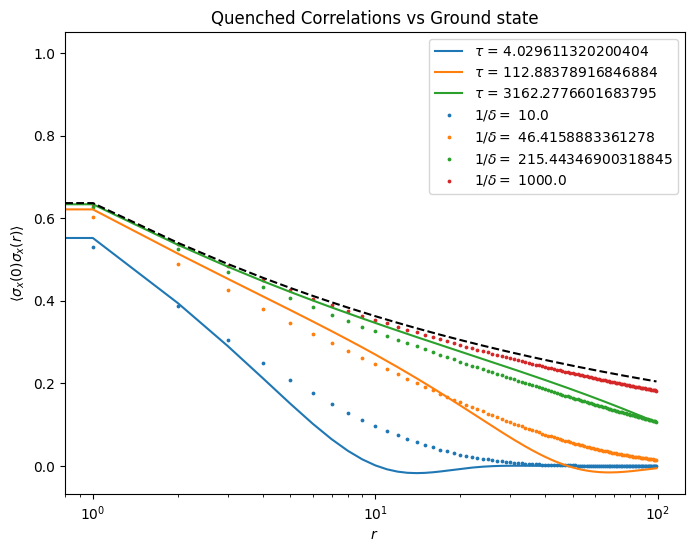

In [16]:
plt.figure(figsize=(8,6))
for t,y in zip(taus[9::5],kz_correlation_funcs[9::5]):
    plot(r,(y),label=rf"$\tau$ = {t}")

plot(r,C_xx,"--k")

for d, x in zip(delta_values[::-1][::8], kb_correlation_funcs[::-1][::8]):
     scatter(r,x,s=3,label=rf"$1/\delta=$ {1/d}" )
title(r"Quenched Correlations vs Ground state")
ylabel(xx_lab)
xlabel(r"$r$")
#yscale("log")
xscale("log")
legend()
show()

In [42]:
#################
r = np.arange(-100,100)
L = 500
delta_values = np.logspace(-3,-1,25)
taus = np.logspace(-2,3.5,20)
k = kb.k_vals(L)

#Calculate Equilibrium Correlation functions in thermodynamic limit for comparison
xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"
P1 = array([eq.P_n_correlations(1,ri)-eq.P_n(1)**2 for ri in r])
n=4
Pn = array([eq.P_n_correlations(n,ri)-eq.P_n(n)**2 for ri in tqdm(r)])


100%|██████████| 200/200 [00:04<00:00, 42.77it/s]


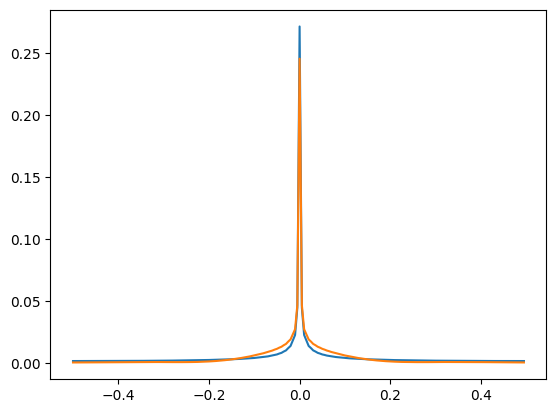

In [43]:
S1 = fftshift(fft(P1))
Sn = fftshift(fft(Pn))

k = fftshift(fftfreq(len(r),1))
S1 /= sum(abs(S1))
Sn /= sum(abs(Sn))

plot(k,abs(S1))
plot(k,abs(Sn))

In [46]:
from scipy.interpolate import interp1d

def fwhm(x, y):
    y = np.abs(y)
    half = np.max(y) / 2.0
    indices = np.where(np.diff(np.sign(y - half)))[0]
    if len(indices) >= 2:
        x1, x2 = x[indices[0]], x[indices[-1]]
        return x2 - x1
    else:
        return np.nan
    

def FT(dat):
    return fftshift(fft(dat))

In [47]:
kz_structure_factors = [FT(x) for x in kz_correlation_funcs]

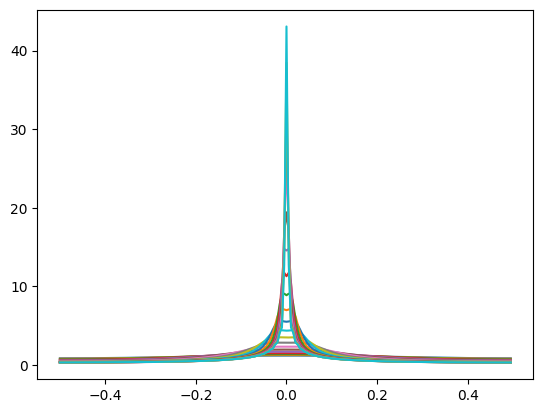

In [59]:
fwhms =[]
for x in kz_structure_factors:
    plot(k,abs(x))
    fwhms.append(fwhm(k,abs(x)))



[]

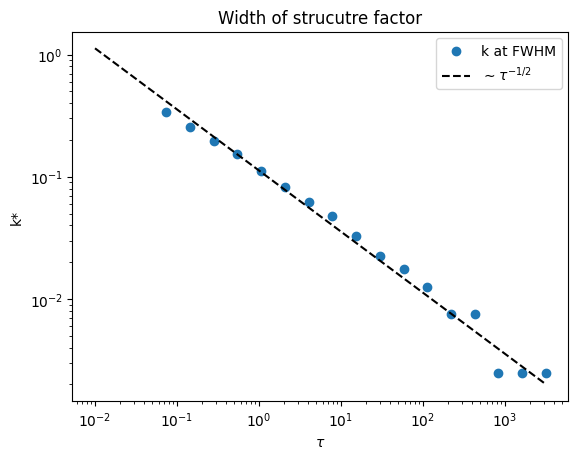

In [72]:
scatter(taus,array(fwhms)/2,label="k at FWHM")
plot(taus,1/(2*pi*sqrt(2*taus)),"--k",label=r"$\sim \tau^{-1/2}$")
xlabel(r"$\tau$")
ylabel(r"k*")
title("Width of strucutre factor")
legend()
loglog()